<a href="https://colab.research.google.com/github/davidsjohnson/blockies-xai/blob/iui2026-xai/blockies_v2_dataselection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pathlib
import os
import sys
from pathlib import Path
import tarfile
import random
import shutil

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms as T

from PIL import Image


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

torch.backends.cudnn.benchmark = True

In [5]:
torch.__version__

'2.8.0+cu126'

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Params

In [7]:
# CLASSES = ['Healthy', 'OC Degeneration 2', 'OC Degeneration 1']
CLASSES = ['Healthy', 'OCDegen']

modeltype = 'resnet18'

ds = 'main_blockies/default'
eval_ds = 'main_blockies/highvar'

random_state = 42
save_dataset = True

In [8]:
gdrive = Path('/content/drive/MyDrive/')
notebook_folder = 'blockiesv2_models_pytorch'

notebook_path = gdrive / notebook_folder
os.makedirs(notebook_path, exist_ok=True)
os.chdir(notebook_path)

In [9]:
relative_model_path = "blockiesv2_models_pytorch"
base_path = Path('/content/drive/MyDrive') / relative_model_path
base_path

PosixPath('/content/drive/MyDrive/blockiesv2_models_pytorch')

In [10]:
model_path = base_path / ds / f'{modeltype}'
print("Model path:", model_path)

# setup checkpoint folders
checkpoint_path = model_path / 'final' / 'best_model.pth'
print("Checkpoint path:", checkpoint_path)

Model path: /content/drive/MyDrive/blockiesv2_models_pytorch/main_blockies/default/resnet18
Checkpoint path: /content/drive/MyDrive/blockiesv2_models_pytorch/main_blockies/default/resnet18/final/best_model.pth


In [11]:
# regression model path
r_model_path = base_path / ds / f'{modeltype}_concepts'
print("Model path:", model_path)

# setup checkpoint folders
r_checkpoint_path = r_model_path / 'final' / 'best_model.pth'
print("Checkpoint path:", r_checkpoint_path)

Model path: /content/drive/MyDrive/blockiesv2_models_pytorch/main_blockies/default/resnet18
Checkpoint path: /content/drive/MyDrive/blockiesv2_models_pytorch/main_blockies/default/resnet18_concepts/final/best_model.pth


# Setup and Load Datasets

In [12]:
# data downloading and dataset utilities

def download_file(url, file_name, cache_dir="data", extract=True, force_download=False, archive_folder=None):
    # Ensure the cache directory exists
    os.makedirs(cache_dir, exist_ok=True)
    file_path = Path(cache_dir) / file_name

    # Download the file
    if not os.path.exists(file_path) or force_download:
      torch.hub.download_url_to_file(url, file_path)
      print(f"File downloaded to: {file_path}")
    else:
      print(f"File already exists at: {file_path}")

    if extract:
      with tarfile.open(file_path, "r:gz") as tar:
          tar.extractall(path=cache_dir)
      print(f"File extracted to: {cache_dir}")
      file_path = Path(cache_dir) / archive_folder if archive_folder is not None else Path(cache_dir)
    elif not extract and archive_folder is not None:
       file_path = Path(cache_dir) / archive_folder
       print(f"File already extracted to: {file_path}")

    return Path(file_path)

def load_dataframe(data_dir, dataset):
  data_dir = data_dir / dataset
  df = pd.read_json(data_dir / 'parameters.jsonl', lines=True, dtype={'sec_bones': str})
  df['filename'] = df['id'] + '.png'
  df['ill'] = (df['obj_name'] == 'ocd').astype(int)
  df['sphere_diff'] = (df.main_spherical - df.sec_spherical).abs()
  df['num_sec_bones'] = df.sec_bones.apply(lambda x: x.count('1'))

  return df

class ImageDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.df.iloc[idx]['filename'])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx]['ill'])

        if self.transform:
            image = self.transform(image)

        return image, label

# data selection processing
def check_range(df, column, range):
    return (abs(df[column]) > range[0]) & (abs(df[column]) < range[1])

In [13]:
# download data direcly from sciebo
# (or setup own data location if prefered)
data_dir = download_file(url="https://uni-bielefeld.sciebo.de/s/yfEHoeqfJq4rK7R/download",
                         file_name="blockies_datasets.tar.gz",
                         cache_dir='/content/data', # change this if not using Colab
                         extract=True,
                         force_download=False,
                         archive_folder='blockies_datasets')
data_dir

100%|██████████| 3.39G/3.39G [02:18<00:00, 26.3MB/s]
/tmp/ipython-input-237025007.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=cache_dir)


File downloaded to: /content/data/blockies_datasets.tar.gz
File extracted to: /content/data


PosixPath('/content/data/blockies_datasets')

In [14]:
ds_dir = data_dir / ds
eval_ds_dir = data_dir / eval_ds
ds_dir, eval_ds_dir

(PosixPath('/content/data/blockies_datasets/main_blockies/default'),
 PosixPath('/content/data/blockies_datasets/main_blockies/highvar'))

In [15]:
train_df = load_dataframe(ds_dir, 'train')
val_df = load_dataframe(ds_dir, 'validation')
test_df = load_dataframe(ds_dir, 'test')
eval_df = load_dataframe(eval_ds_dir, 'test')

print(len(train_df), len(val_df), len(test_df), len(eval_df))

40000 1000 2000 2000


In [16]:
# load predictions from normal model
test_pred_df = pd.read_csv(model_path / 'test_preds.csv')
eval_pred_df = pd.read_csv(model_path / 'eval_preds.csv')

test_df['pred'] = test_pred_df['pred']
eval_df['pred'] = eval_pred_df['pred']

In [17]:
# load predictions from concept model
concept_pred_cols = [
    'main_spherical_pred',
    'sec_spherical_pred',
    'bending_pred',
    'arm_position_pred',
    'num_sec_bones_pred',
    'obj_rotation_roll_pred',
    'obj_rotation_pitch_pred',
    'obj_rotation_yaw_pred',
    'position_x_pred',
    'position_y_pred',
    'obj_color_pred',
    'bg_color_pred'
    ]

test_pred_df = pd.read_csv(r_model_path / 'test_preds.csv')
eval_pred_df = pd.read_csv(r_model_path / 'eval_preds.csv')

test_df[concept_pred_cols] = test_pred_df[concept_pred_cols]
eval_df[concept_pred_cols] = eval_pred_df[concept_pred_cols]

test_df['concept_pred'] = test_pred_df['pred']
eval_df['concept_pred'] = eval_pred_df['pred']

In [18]:
# check normal model accuracies
test_acc = (test_df['pred'] == test_df['ill']).astype(int).mean()
eval_acc = (eval_df['pred'] == eval_df['ill']).astype(int).mean()

print(f'Test Acc: {test_acc:.4f}')
print(f'Eval Acc: {eval_acc:.4f}')

Test Acc: 0.8970
Eval Acc: 0.7200


In [19]:
# check concept model accuracies
test_acc = (test_df['concept_pred'] == test_df['ill']).astype(int).mean()
eval_acc = (eval_df['concept_pred'] == eval_df['ill']).astype(int).mean()

print(f'Test Acc: {test_acc:.4f}')
print(f'Eval Acc: {eval_acc:.4f}')

Test Acc: 0.9840
Eval Acc: 0.8385


In [20]:
abs(eval_df[['obj_rotation_roll', 'obj_rotation_pitch']]).describe()

,obj_rotation_roll,obj_rotation_pitch
count,2000.000000,2000.000000
mean,0.392246,0.393233
std,0.225112,0.223429
min,0.000981,0.000470
25%,0.197286,0.202824
50%,0.386905,0.389837
75%,0.583396,0.579948
max,0.783714,0.784621


In [21]:
# only use samples where two models predictions are the same
eval_tmp_df = eval_df[eval_df['pred'] == eval_df['concept_pred']]
print(len(eval_df), len(eval_tmp_df))

2000 1511


In [22]:
# same for test dataset used for tutorial
test_temp_df = test_df[test_df['pred'] == test_df['concept_pred']]
print(len(test_df), len(test_temp_df))

2000 1794


In [23]:
# remove some samples from same domain to make task  bit more difficult
roll_range = (.0, .25)
pitch_range = (.0, .25)
roll_remove = check_range(eval_tmp_df, 'obj_rotation_roll', roll_range)
pitch_remove = check_range(eval_tmp_df, 'obj_rotation_pitch', pitch_range)

eval_hard_df = eval_tmp_df.drop(eval_tmp_df[roll_remove | pitch_remove].index)
print(len(eval_tmp_df), len(eval_hard_df))

1511 650


In [24]:
eval_hard_acc = (eval_hard_df['pred'] == eval_hard_df['ill']).astype(int).mean()
print(f'Eval Hard Acc: {eval_hard_acc:.4f}')

Eval Hard Acc: 0.8000


In [25]:
test_temp_acc = (test_temp_df['pred'] == test_temp_df['ill']).astype(int).mean()
print(f'Test Temp Acc: {test_temp_acc:.4f}')

Test Temp Acc: 0.9911


# Data Selection

Review data distributions of all datasets and then select images for XAI and Tutorial datasets

## Data Distributions

view of distribitions for various traits of Blockies.

- `spherical`, `ill_spherical`, and `sphere_dff` all represent the bone shape for the main and secondary bones
- `spherical` values above 1 represent a bone mutation
- `bending` represents the amount of bend in the blockies spines
- `arm_position` represents the amount the arms of the blockies are extened or pulled back, affecting whether or not the head peaks out from between the legs
- `obj_rotation_<X>` represents the `pitch`, `yaw`, or `roll` of the bodies (depending on the value of X)


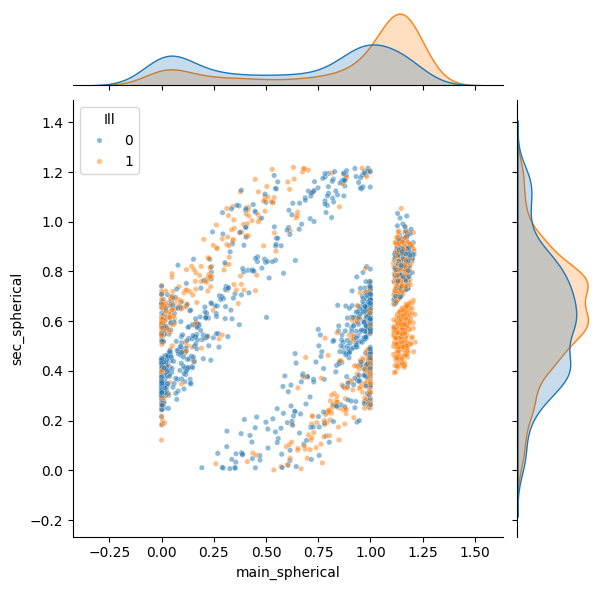

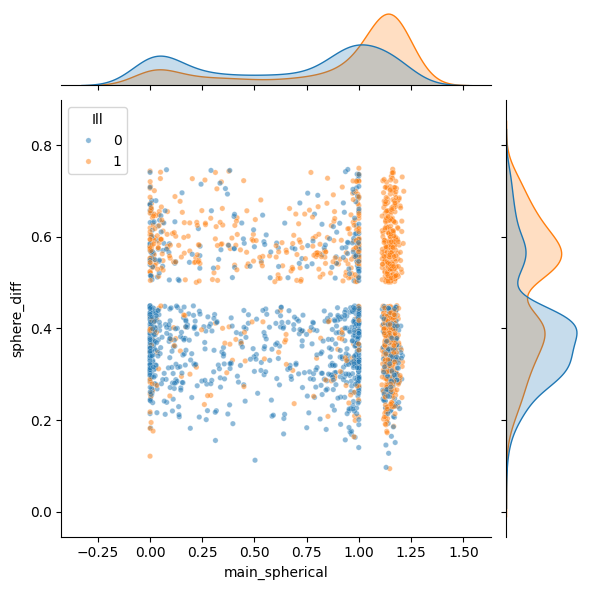

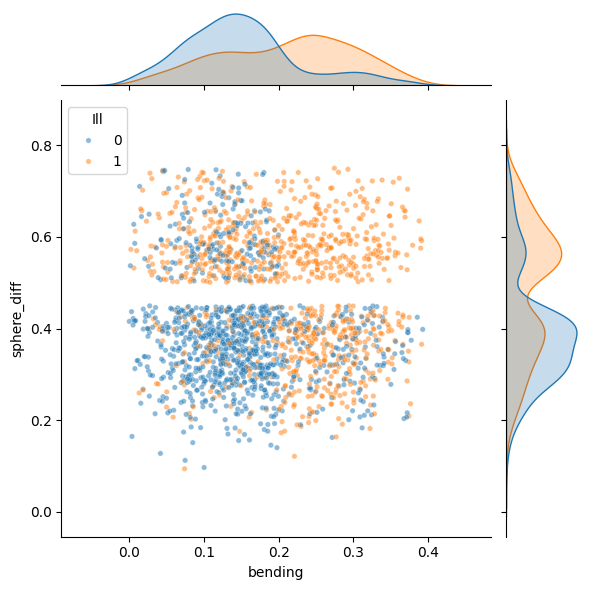

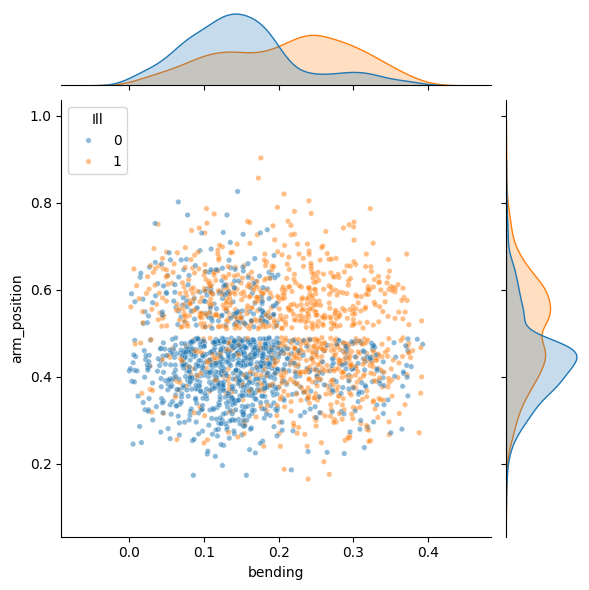

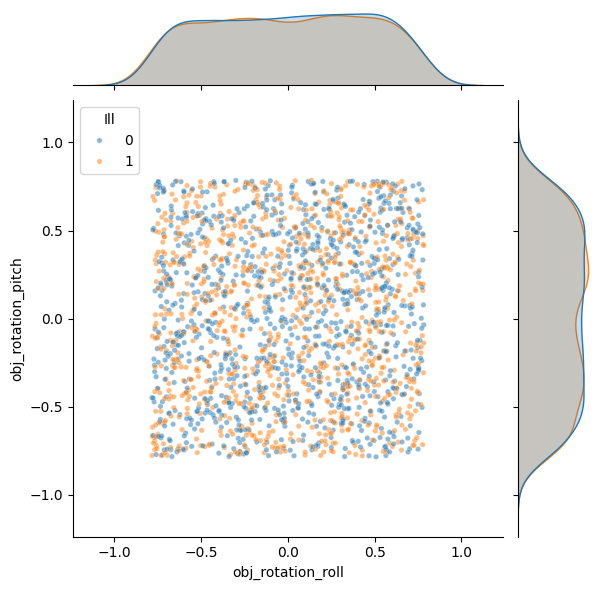

In [26]:
g = sns.jointplot(data=eval_df, x='main_spherical', y='sec_spherical', hue='ill', s=15, alpha=0.5)
sns.move_legend(g.ax_joint, "upper left", title='Ill', frameon=True)
# g.ax_joint.scatter(eval_df[~eval_corr_pred]['spherical'], eval_df[~eval_corr_pred]['ill_spherical'], color='black', alpha=0.49, s=50, zorder=1, linewidth=2)


g = sns.jointplot(data=eval_df, x='main_spherical', y='sphere_diff', hue='ill', s=15, alpha=0.5)
sns.move_legend(g.ax_joint, "upper left", title='Ill', frameon=True)
# g.ax_joint.scatter(eval_df[~eval_corr_pred]['spherical'], eval_df[~eval_corr_pred]['sphere_diff'], color='black', alpha=0.49, s=50, zorder=1, linewidth=2)

g = sns.jointplot(data=eval_df, x='bending', y='sphere_diff', hue='ill', s=15, alpha=0.5)
sns.move_legend(g.ax_joint, "upper left", title='Ill', frameon=True)
# g.ax_joint.scatter(eval_df[~eval_corr_pred]['bending'], eval_df[~eval_corr_pred]['sphere_diff'], color='black', alpha=0.49, s=50, zorder=1, linewidth=2)

g = sns.jointplot(data=eval_df, x='bending', y='arm_position', hue='ill', s=15, alpha=0.5)
sns.move_legend(g.ax_joint, "upper left", title='Ill', frameon=True)
# g.ax_joint.scatter(eval_df[~eval_corr_pred]['bending'], eval_df[~eval_corr_pred]['arm_position'], color='black', alpha=0.49, s=50, zorder=1, linewidth=2)

g = sns.jointplot(data=eval_df, x='obj_rotation_roll', y='obj_rotation_pitch', hue='ill', s=15, alpha=0.5)
sns.move_legend(g.ax_joint, "upper left", title='Ill', frameon=True)
# g.ax_joint.scatter(eval_df[~eval_corr_pred]['obj_rotation_roll'], eval_df[~eval_corr_pred]['obj_rotation_pitch'], color='black', alpha=0.49, s=50, zorder=1, linewidth=2)

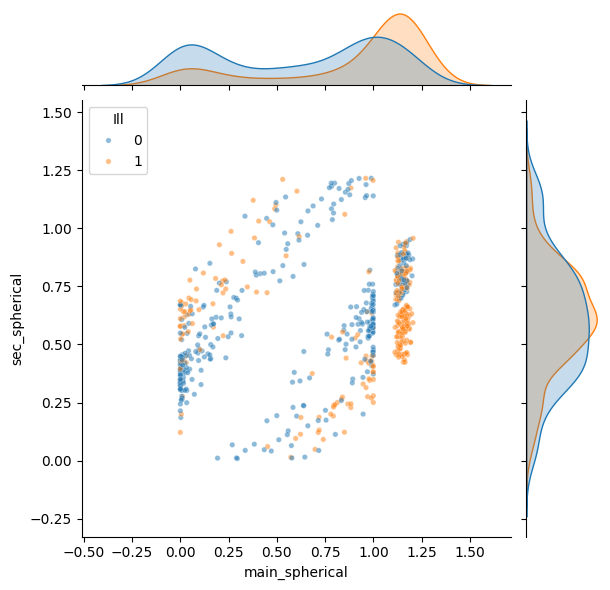

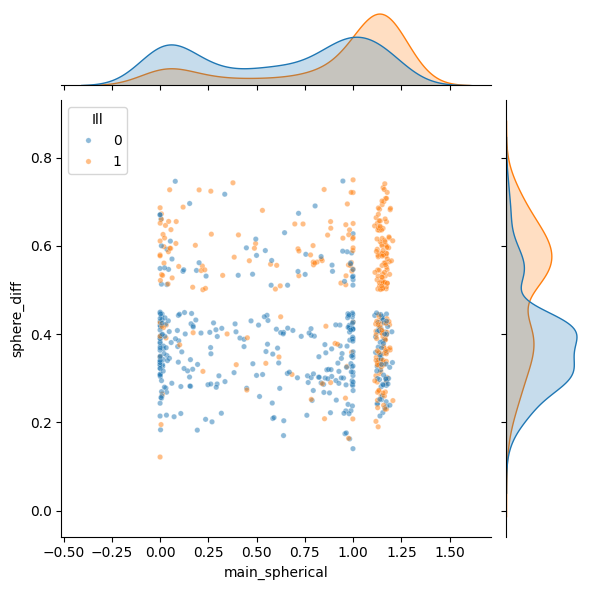

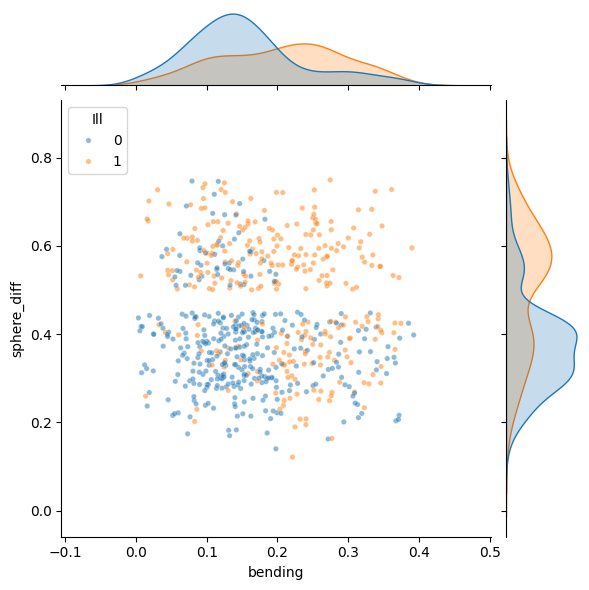

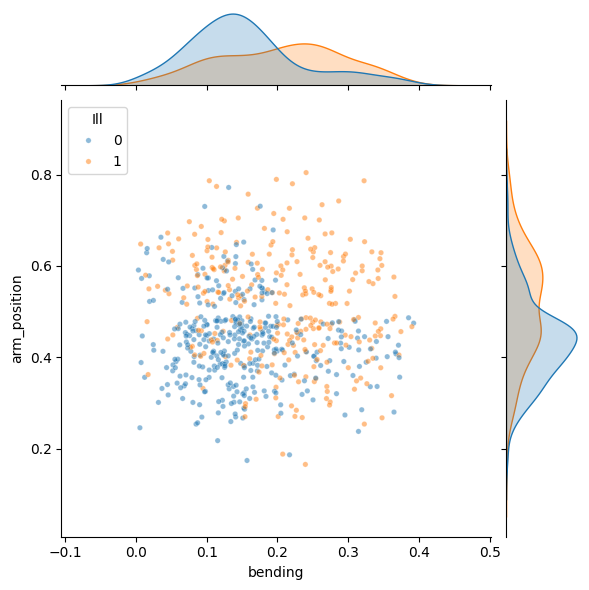

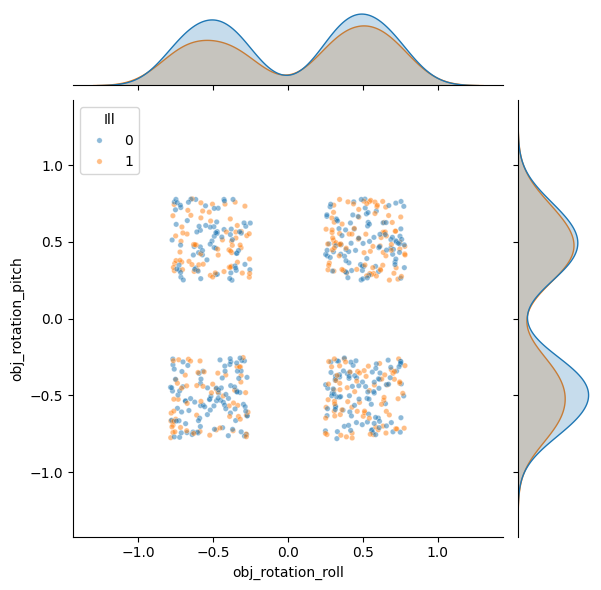

In [27]:
g = sns.jointplot(data=eval_hard_df, x='main_spherical', y='sec_spherical', hue='ill', s=15, alpha=0.5)
sns.move_legend(g.ax_joint, "upper left", title='Ill', frameon=True)
# g.ax_joint.scatter(eval_hard_df[~eval_hard_corr_pred]['spherical'], eval_hard_df[~eval_hard_corr_pred]['ill_spherical'], color='black', alpha=0.49, s=50, zorder=1, linewidth=2)


g = sns.jointplot(data=eval_hard_df, x='main_spherical', y='sphere_diff', hue='ill', s=15, alpha=0.5)
sns.move_legend(g.ax_joint, "upper left", title='Ill', frameon=True)
# g.ax_joint.scatter(eval_hard_df[~eval_hard_corr_pred]['spherical'], eval_hard_df[~eval_hard_corr_pred]['sphere_diff'], color='black', alpha=0.49, s=50, zorder=1, linewidth=2)

g = sns.jointplot(data=eval_hard_df, x='bending', y='sphere_diff', hue='ill', s=15, alpha=0.5)
sns.move_legend(g.ax_joint, "upper left", title='Ill', frameon=True)
# g.ax_joint.scatter(eval_hard_df[~eval_hard_corr_pred]['bending'], eval_hard_df[~eval_hard_corr_pred]['sphere_diff'], color='black', alpha=0.49, s=50, zorder=1, linewidth=2)

g = sns.jointplot(data=eval_hard_df, x='bending', y='arm_position', hue='ill', s=15, alpha=0.5)
sns.move_legend(g.ax_joint, "upper left", title='Ill', frameon=True)
# g.ax_joint.scatter(eval_hard_df[~eval_hard_corr_pred]['bending'], eval_hard_df[~eval_hard_corr_pred]['arm_position'], color='black', alpha=0.49, s=50, zorder=1, linewidth=2)


g = sns.jointplot(data=eval_hard_df, x='obj_rotation_roll', y='obj_rotation_pitch', hue='ill', s=15, alpha=0.5)
sns.move_legend(g.ax_joint, "upper left", title='Ill', frameon=True)
# g.ax_joint.scatter(eval_hard_df[~eval_hard_corr_pred]['obj_rotation_roll'], eval_hard_df[~eval_hard_corr_pred]['obj_rotation_pitch'], color='black', alpha=0.49, s=50, zorder=1, linewidth=2)

## Generate Explanation Dataset

- 32 - Correct predictions
- 8 - Incorrect predictions

represents accuracy of model (around $80\%$)


In [28]:
def display_images(df, n_rows, n_cols, img_dir, title, random_state=0):
  """ Function to display images in a grid randomly selected from a dataframe of images.

  Args:
    df (pd.DataFrame): dataframe of images
    n_rows (int): number of rows in the grid
    n_cols (int): number of columns in the grid
    title (str): title of the plot
    random_state (int): random state for reproducibility
  """

  if n_rows == 0 and n_cols == 0:
    print(f'Not data to display for Figure - {title}')
    return

  if n_rows * n_cols < len(df):
    df = df.sample(n_rows * n_cols, random_state=random_state)

  figsize = (n_cols * 2, n_rows*2.5)
  print(figsize)

  test_images = np.array([Image.open(p).convert('RGB') for p in img_dir / df['filename']]) * 1. / 255
  fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
  axes = np.array(axes)
  for i, (ax, idx) in enumerate(zip(axes.flat, df.index)):
    ax.imshow(test_images[i])
    ax.set_title(f'True={df.loc[idx]["ill"]} - Pred={df.loc[idx]["pred"]}')
    ax.axis('off')

  fig.suptitle(title)
  fig.tight_layout()

In [29]:
eval_hard_corr = eval_hard_df['ill'] == eval_hard_df['pred']

In [30]:
# for 2 class problem
# correct
samples_corr = eval_hard_df[eval_hard_corr].groupby(['ill']).sample(16, random_state=random_state)

# incorrect 4 from each class, 2 per predict
samples_inc = eval_hard_df[~eval_hard_corr].groupby(['ill', 'pred']).sample(4, random_state=random_state)

xai_df = pd.concat([samples_corr, samples_inc])
xai_corr = xai_df['ill'].astype(int) == xai_df['pred']
print(f'Acc: {xai_corr.astype(int).mean():.4f}')
xai_df.describe()

Acc: 0.8000


,num_ill_chars,main_spherical,sec_spherical,bending,obj_rotation_roll,obj_rotation_pitch,obj_rotation_yaw,position_x,position_y,arm_position,...,arm_position_pred,num_sec_bones_pred,obj_rotation_roll_pred,obj_rotation_pitch_pred,obj_rotation_yaw_pred,position_x_pred,position_y_pred,obj_color_pred,bg_color_pred,concept_pred
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,...,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.00000
mean,1.525000,0.758679,0.616627,0.185981,-0.028087,0.012706,-1.129519,-0.406795,-0.404124,0.483961,...,0.462844,1.990612,0.008761,0.055183,-1.128453,-0.436554,-0.403192,0.462379,0.475961,0.50000
std,0.905468,0.445684,0.237110,0.090533,0.519561,0.540756,0.738650,0.215735,0.218534,0.136462,...,0.146420,0.526572,0.036732,0.480917,0.704880,0.215429,0.215911,0.326847,0.269696,0.50637
min,0.000000,0.000077,0.113211,0.012181,-0.774502,-0.765478,-2.339735,-0.759700,-0.728623,0.173797,...,0.109096,1.004057,-0.054244,-0.645596,-2.333408,-0.787879,-0.802433,-0.050872,0.047844,0.00000
25%,1.000000,0.353716,0.440388,0.115731,-0.513775,-0.518846,-1.909773,-0.624667,-0.588452,0.417360,...,0.349281,1.843301,-0.025766,-0.403316,-1.892527,-0.623838,-0.545353,0.199261,0.250956,0.00000
50%,1.500000,0.980512,0.614716,0.164639,0.271485,0.008039,-0.927680,-0.413694,-0.420922,0.480240,...,0.479049,2.002032,0.011644,0.065564,-0.940862,-0.471433,-0.442251,0.381512,0.477309,0.50000
75%,2.000000,1.138854,0.802404,0.249472,0.404425,0.536202,-0.515517,-0.215560,-0.263904,0.585992,...,0.548406,2.148221,0.037893,0.514128,-0.488321,-0.256143,-0.314830,0.748473,0.715160,1.00000
max,3.000000,1.175957,1.131905,0.366786,0.716971,0.761399,-0.028322,-0.065214,-0.011258,0.774189,...,0.786158,2.990574,0.081432,0.766786,-0.133303,-0.022765,0.150420,0.968726,0.920281,1.00000


### View XAI dataset distribution

correct samples in black, incorrect samples in red

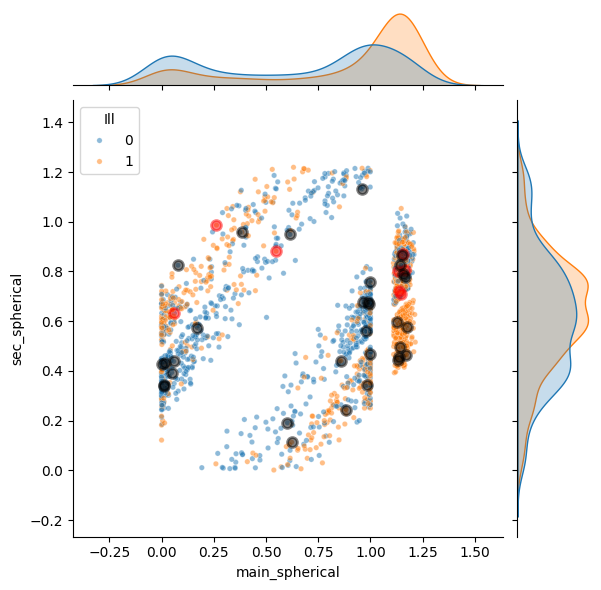

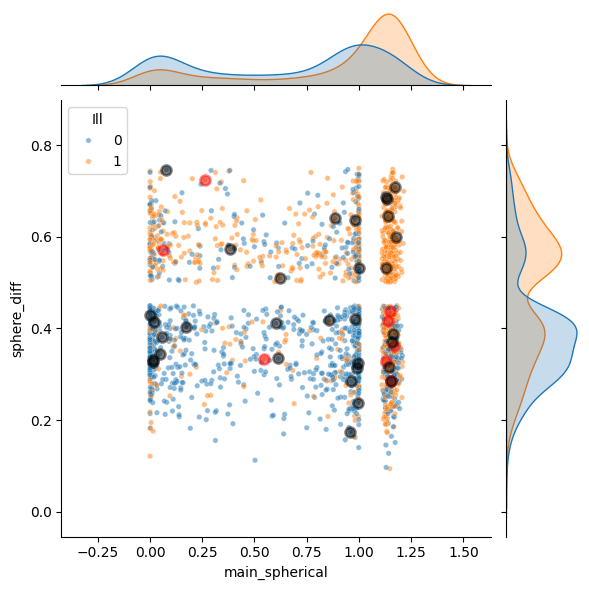

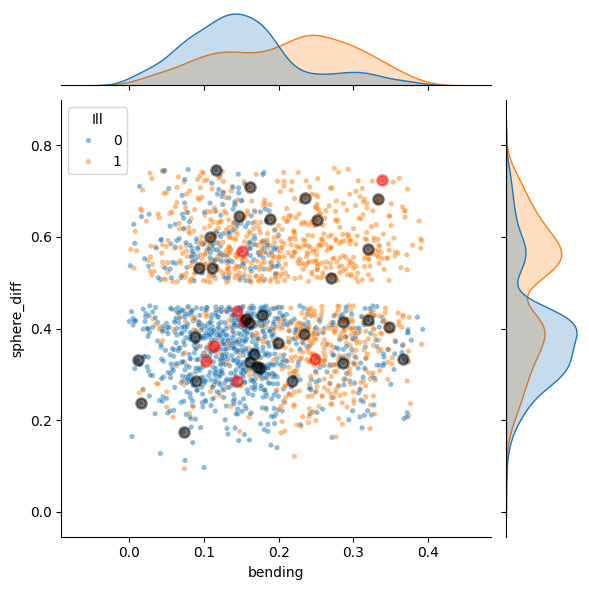

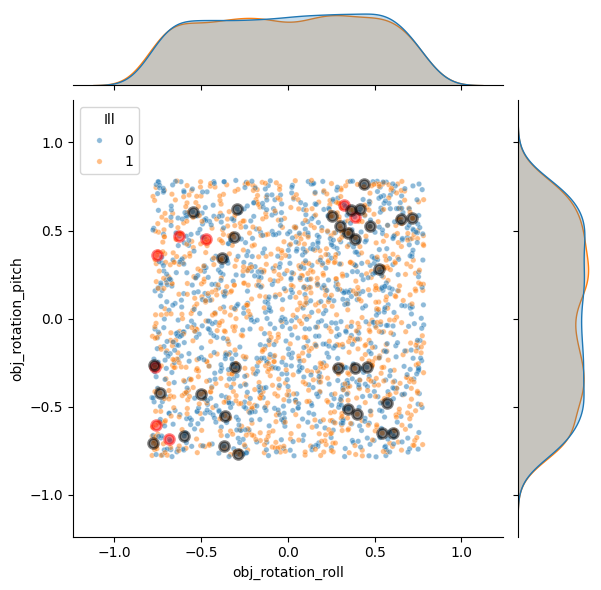

In [31]:
g = sns.jointplot(data=eval_df, x='main_spherical', y='sec_spherical', hue='ill', s=15, alpha=0.5)
sns.move_legend(g.ax_joint, "upper left", title='Ill', frameon=True)
g.ax_joint.scatter(xai_df[~xai_corr]['main_spherical'], xai_df[~xai_corr]['sec_spherical'], color='red', alpha=0.49, s=50, zorder=1, linewidth=2)
g.ax_joint.scatter(xai_df[xai_corr]['main_spherical'], xai_df[xai_corr]['sec_spherical'], color='black', alpha=0.49, s=50, zorder=1, linewidth=2)


g = sns.jointplot(data=eval_df, x='main_spherical', y='sphere_diff', hue='ill', s=15, alpha=0.5)
sns.move_legend(g.ax_joint, "upper left", title='Ill', frameon=True)
g.ax_joint.scatter(xai_df[~xai_corr]['main_spherical'], xai_df[~xai_corr]['sphere_diff'], color='red', alpha=0.49, s=50, zorder=1, linewidth=2)
g.ax_joint.scatter(xai_df[xai_corr]['main_spherical'], xai_df[xai_corr]['sphere_diff'], color='black', alpha=0.49, s=50, zorder=1, linewidth=2)

g = sns.jointplot(data=eval_df, x='bending', y='sphere_diff', hue='ill', s=15, alpha=0.5)
sns.move_legend(g.ax_joint, "upper left", title='Ill', frameon=True)
g.ax_joint.scatter(xai_df[~xai_corr]['bending'], xai_df[~xai_corr]['sphere_diff'], color='red', alpha=0.49, s=50, zorder=1, linewidth=2)
g.ax_joint.scatter(xai_df[xai_corr]['bending'], xai_df[xai_corr]['sphere_diff'], color='black', alpha=0.49, s=50, zorder=1, linewidth=2)

g = sns.jointplot(data=eval_df, x='obj_rotation_roll', y='obj_rotation_pitch', hue='ill', s=15, alpha=0.5)
sns.move_legend(g.ax_joint, "upper left", title='Ill', frameon=True)
g.ax_joint.scatter(xai_df[~xai_corr]['obj_rotation_roll'], xai_df[~xai_corr]['obj_rotation_pitch'], color='red', alpha=0.49, s=50, zorder=1, linewidth=2)
g.ax_joint.scatter(xai_df[xai_corr]['obj_rotation_roll'], xai_df[xai_corr]['obj_rotation_pitch'], color='black', alpha=0.49, s=50, zorder=1, linewidth=2)

### View Selected Dataset

(8, 20.0)


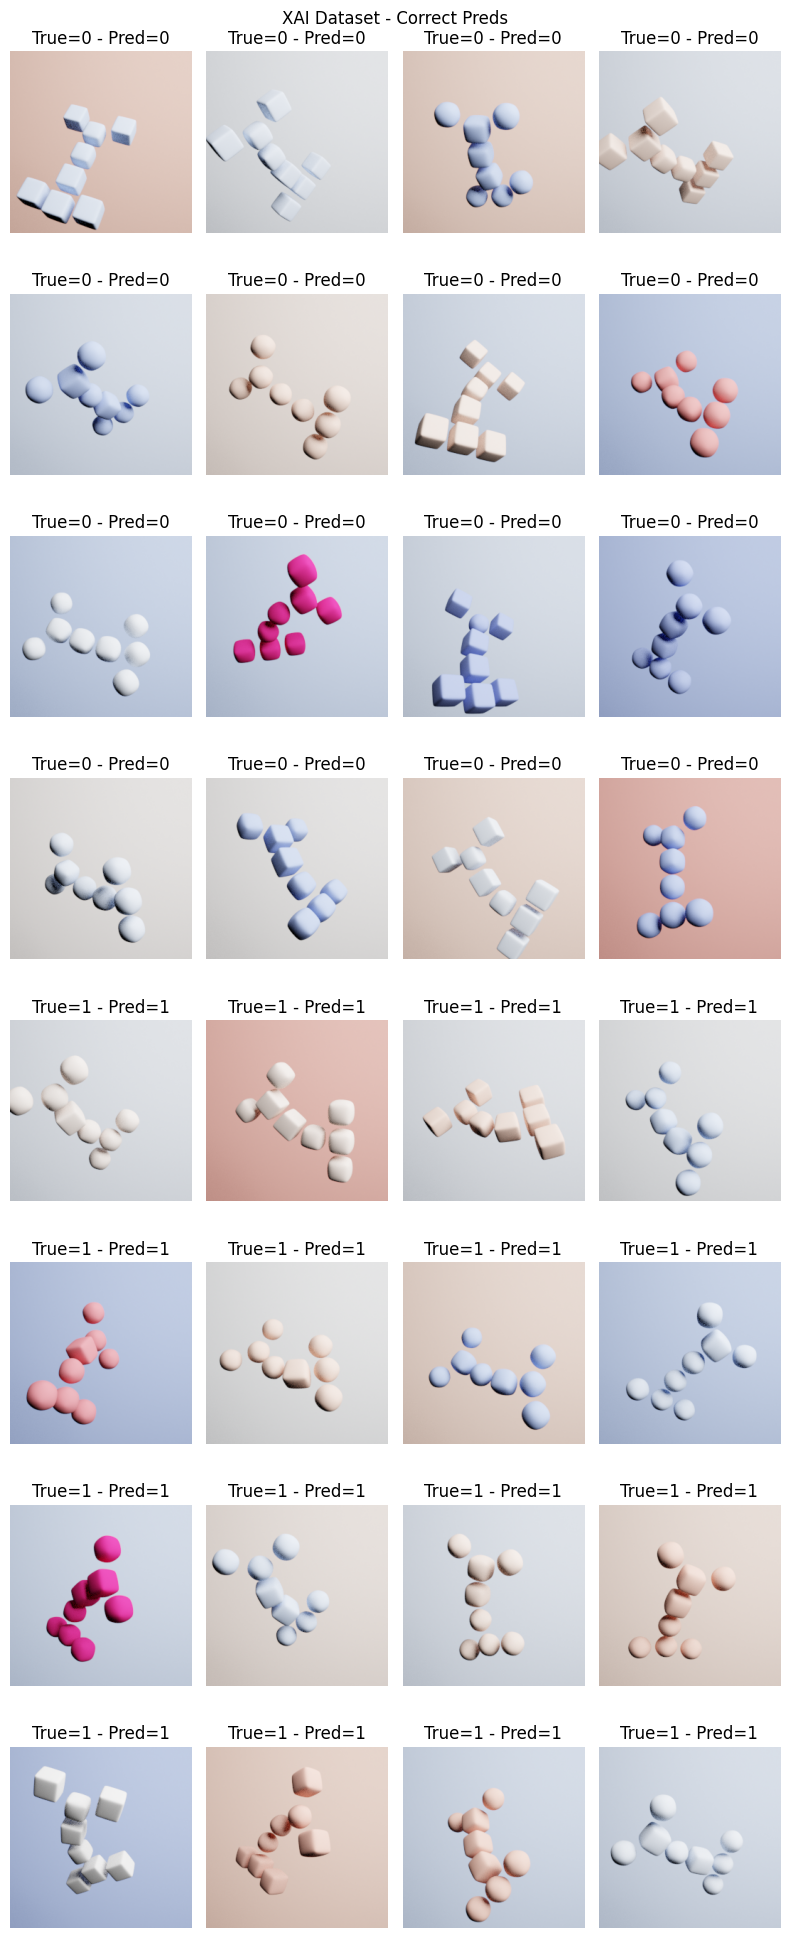

In [32]:
display_images(xai_df[xai_corr], 8, 4, eval_ds_dir / 'test', f'XAI Dataset - Correct Preds', random_state=0)

(8, 5.0)


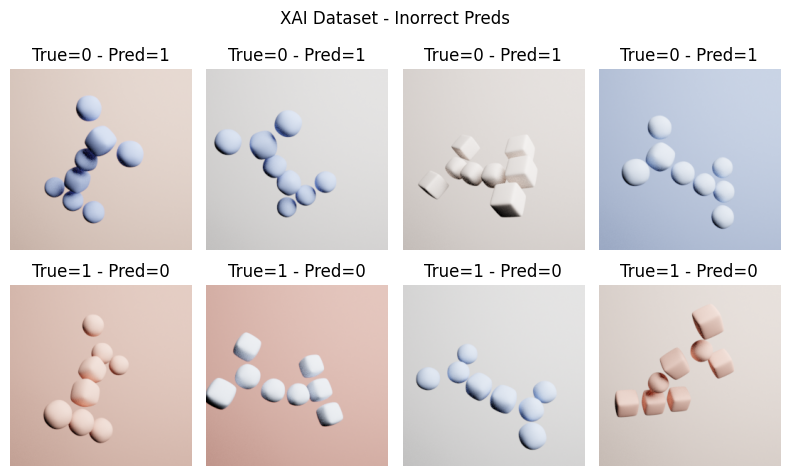

In [33]:
display_images(xai_df[~xai_corr], 2, 4, eval_ds_dir / 'test', f'XAI Dataset - Inorrect Preds', random_state=0)

### Shuffle Data and prepare data

In [39]:
def shuffle_dataset(df, n_correct, random_state=9):

  # get n correct instances for beginning of df
  correct_df = df[df['ill'] == df['pred']]
  correct_healthy_samples = correct_df[correct_df['ill'] == 0].sample(n_correct // 2, random_state=random_state)
  correct_ocd_samples = correct_df[correct_df['ill'] == 1].sample(n_correct // 2, random_state=random_state)
  correct_samples_df = pd.concat([correct_healthy_samples, correct_ocd_samples])
  correct_samples_df = correct_samples_df.sample(frac=1, random_state=random_state)

  # shuffle remaining instances
  remaining_df = df.drop(correct_samples_df.index).reset_index(drop=True)
  remaining_df = remaining_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

  # add correct instances to beginning of df
  final_df = pd.concat([correct_samples_df, remaining_df]).reset_index(drop=True)

  return final_df

In [44]:
import string
def generate_random_id(length=10):
    return ''.join(
        random.choices(string.ascii_uppercase + string.digits, k=length)
    )

def add_fake_id(df, length=10):
  df['p_id'] = df.apply(lambda x: generate_random_id(length), axis=1)
  # check for duplicate p_ids
  assert len(df['p_id'].unique()) == len(df), "Duplicate p_ids found"
  return df


In [ ]:
n_correct = 6
xai_df = add_fake_id(xai_df, length=8)
xai_df = shuffle_dataset(xai_df, 6, random_state=random_state)

xai_df2 = shuffle_dataset(xai_df, 6, random_state=random_state*2)

In [50]:
assert (xai_df.iloc[:n_correct]['ill'] == xai_df.iloc[:n_correct]['pred']).astype(int).mean() == 1, "First n samples should be correct"

### Save Inputs

In [51]:
from skimage.transform import resize
import datetime

In [52]:
def show_blocky(image, id, pred=None):

  figsize = [5, 5]
  fig, ax = plt.subplots(nrows=1, ncols=1, figsize=figsize)

  #plot the input image
  ax.imshow(image)
  ax.axis('off')

In [53]:
output = gdrive / 'hcxai_studies' / 'xai_study1'

In [ ]:
if save_dataset:
  img_paths = xai_df['filename'].apply(lambda x: eval_ds_dir / 'test' / x)

  today = datetime.datetime.today()
  date_str = today.strftime('%Y-%m-%d')

  o = output / 'resnet18' / date_str / 'main_data' / f'xai_samples'
  os.makedirs(o, exist_ok=True)
  print(f'copying images to {o}')

  for p in img_paths:
    shutil.copy(p, o)

  # save dataframe
  xai_df.to_csv(o / 'xai_samples_df.csv')
  xai_df2.to_csv(o / 'xai_samples_df2.csv')

copying images to /content/drive/MyDrive/hcxai_studies/xai_study1/resnet18/2025-08-26/main_data/xai_samples


## Generate Tutorial Dataset

Generate seperate sample of data to use in the tutorial

In [55]:
test_corr = test_temp_df['ill'] == test_temp_df['pred']

In [56]:
# 15 easy examples for tutorial (80 % accuracy)

rot_max = 0.50
roll_limited = check_range(test_temp_df, 'obj_rotation_roll', (0, rot_max))
pitch_limited = check_range(test_temp_df, 'obj_rotation_pitch', (0, rot_max))

# correct
train_samples_corr = test_temp_df[test_corr].groupby(['ill']).sample(6, random_state=random_state)

# incorrect 4 from each class, 2 per predict
tutor_samples_inc = test_temp_df[~test_corr].groupby(['ill']).sample(4, random_state=random_state)

print(len(train_samples_corr), len(tutor_samples_inc))

tutor_df = pd.concat([train_samples_corr, tutor_samples_inc])
tutor_corr = tutor_df['ill'].astype(int) == tutor_df['pred']
print(f'Acc: {tutor_corr.astype(int).mean():.4f}')

12 8
Acc: 0.6000


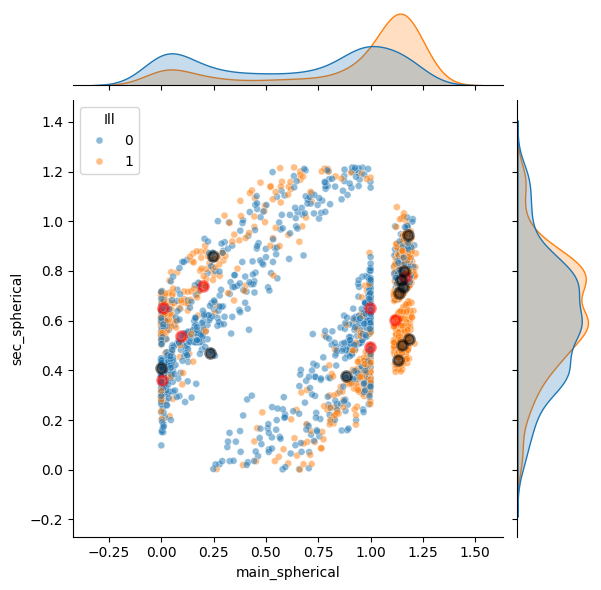

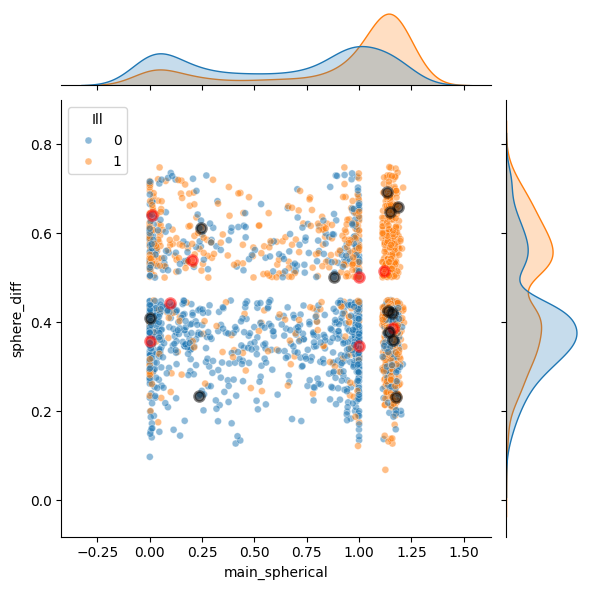

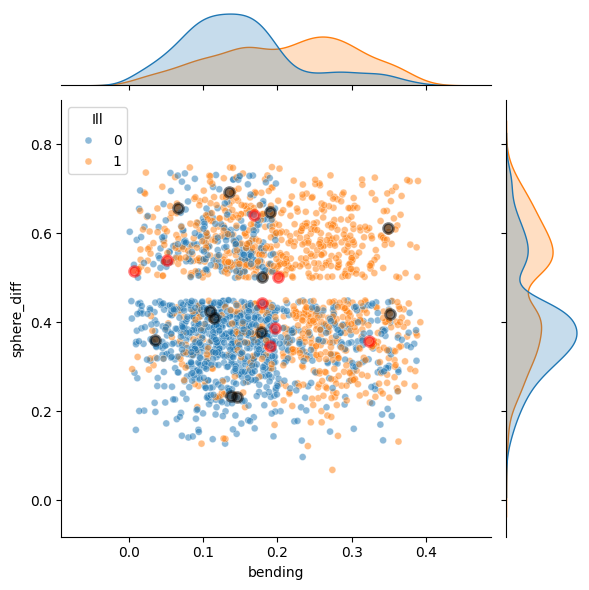

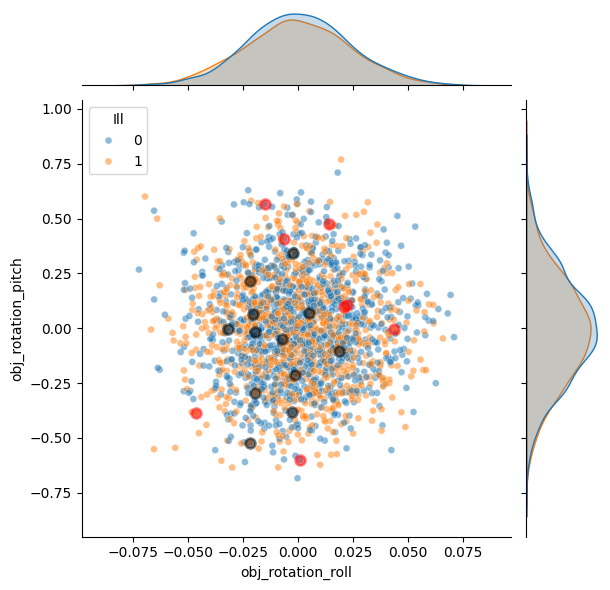

In [59]:
g = sns.jointplot(data=test_df, x='main_spherical', y='sec_spherical', hue='ill', s=25, alpha=0.5)
sns.move_legend(g.ax_joint, "upper left", title='Ill', frameon=True)
g.ax_joint.scatter(tutor_df[~tutor_corr]['main_spherical'], tutor_df[~tutor_corr]['sec_spherical'], color='red', alpha=0.49, s=50, zorder=1, linewidth=2)
g.ax_joint.scatter(tutor_df[tutor_corr]['main_spherical'], tutor_df[tutor_corr]['sec_spherical'], color='black', alpha=0.49, s=50, zorder=1, linewidth=2)

g = sns.jointplot(data=test_df, x='main_spherical', y='sphere_diff', hue='ill', s=25, alpha=0.5)
sns.move_legend(g.ax_joint, "upper left", title='Ill', frameon=True)
g.ax_joint.scatter(tutor_df[~tutor_corr]['main_spherical'], tutor_df[~tutor_corr]['sphere_diff'], color='red', alpha=0.49, s=50, zorder=1, linewidth=2)
g.ax_joint.scatter(tutor_df[tutor_corr]['main_spherical'], tutor_df[tutor_corr]['sphere_diff'], color='black', alpha=0.49, s=50, zorder=1, linewidth=2)

g = sns.jointplot(data=test_df, x='bending', y='sphere_diff', hue='ill', s=25, alpha=0.5)
sns.move_legend(g.ax_joint, "upper left", title='Ill', frameon=True)
g.ax_joint.scatter(tutor_df[~tutor_corr]['bending'], tutor_df[~tutor_corr]['sphere_diff'], color='red', alpha=0.49, s=50, zorder=1, linewidth=2)
g.ax_joint.scatter(tutor_df[tutor_corr]['bending'], tutor_df[tutor_corr]['sphere_diff'], color='black', alpha=0.49, s=50, zorder=1, linewidth=2)


g = sns.jointplot(data=test_df, x='obj_rotation_roll', y='obj_rotation_pitch', hue='ill', s=25, alpha=0.5)
sns.move_legend(g.ax_joint, "upper left", title='Ill', frameon=True)
g.ax_joint.scatter(tutor_df[~tutor_corr]['obj_rotation_roll'], tutor_df[~tutor_corr]['obj_rotation_pitch'], color='red', alpha=0.49, s=50, zorder=1, linewidth=2)
g.ax_joint.scatter(tutor_df[tutor_corr]['obj_rotation_roll'], tutor_df[tutor_corr]['obj_rotation_pitch'], color='black', alpha=0.49, s=50, zorder=1, linewidth=2)

(8, 12.5)


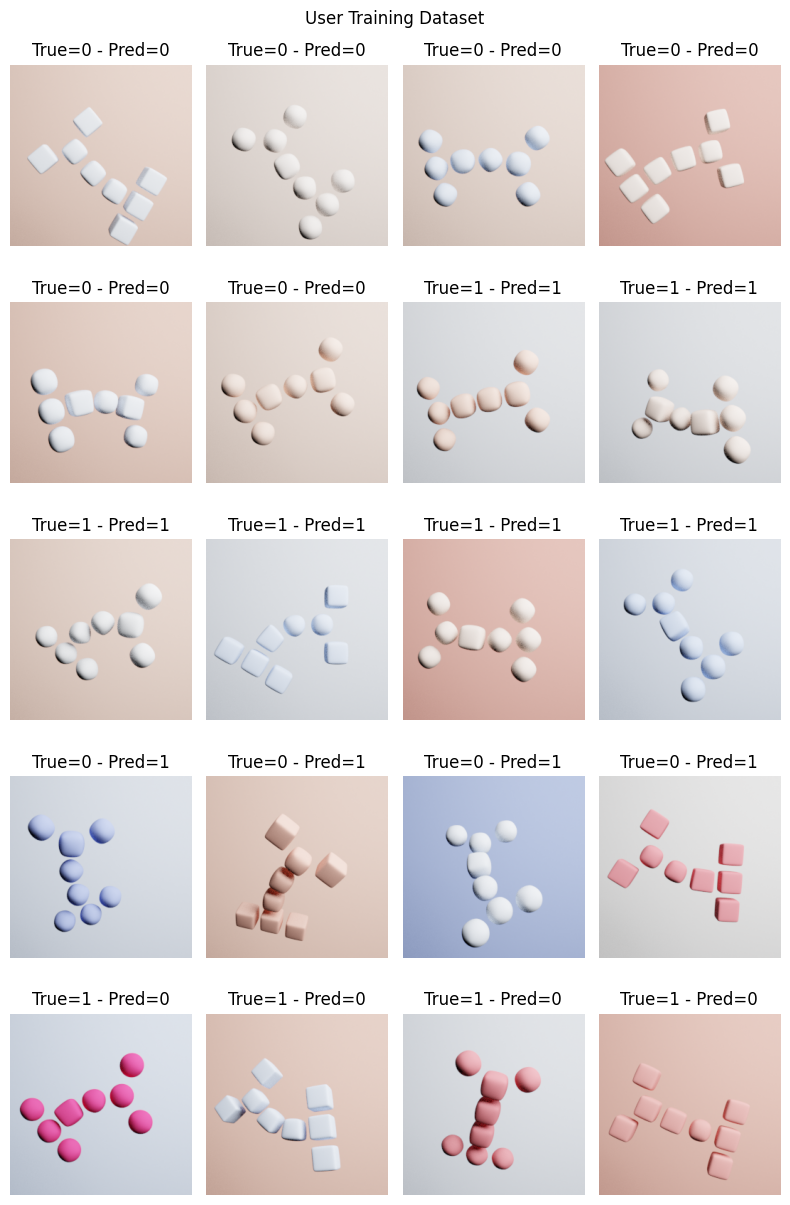

In [60]:
display_images(tutor_df, 5, 4, ds_dir / 'test', 'User Training Dataset')

In [62]:
n_correct = 4
tutor_df = add_fake_id(tutor_df, length=8)
tutor_df = shuffle_dataset(tutor_df, n_correct, random_state=random_state)

In [63]:
assert (tutor_df.iloc[:n_correct]['ill'] == tutor_df.iloc[:n_correct]['pred']).astype(int).mean() == 1, "First n samples should be correct"

In [65]:
tutor_df

,obj_name,num_ill_chars,ill_chars,labeling_error,main_spherical,sec_spherical,sec_bones,bending,obj_rotation_roll,obj_rotation_pitch,...,num_sec_bones_pred,obj_rotation_roll_pred,obj_rotation_pitch_pred,obj_rotation_yaw_pred,position_x_pred,position_y_pred,obj_color_pred,bg_color_pred,concept_pred,p_id
0,healthy,0,[],False,0.000017,0.409325,111,0.114179,-0.020753,0.066567,...,2.999093,-0.004418,0.072603,-0.692874,-0.081312,-0.742821,0.387048,0.788414,0,L6EVZ84W
1,ocd,2,"[mutation_mainbones, stretchy]",False,1.160208,0.799867,111,0.036070,-0.021867,0.217215,...,3.000821,-0.004234,0.224757,-2.892148,-0.522716,-0.411869,0.813291,0.431922,1,ETYTTFXE
2,healthy,1,[mutation_mainbones],False,1.142974,0.765017,010,0.178158,-0.019414,-0.016036,...,1.003278,-0.004722,-0.005522,-0.874159,-0.087571,-0.567660,0.579316,0.637705,0,CL8DGCAI
3,ocd,2,"[high_sphere_diff, mutation_mainbones]",False,1.148742,0.499930,101,0.189939,-0.022115,-0.521287,...,2.023881,0.003583,-0.525941,-0.063590,-0.230748,-0.758103,0.640298,0.437758,1,L4FEWW6U
4,healthy,1,[mutation_mainbones],False,1.177986,0.946440,101,0.145115,0.004960,0.070674,...,2.001482,0.001952,0.055825,-3.062939,-0.407820,-0.505161,0.292829,0.714486,0,OMQ74FQM
5,healthy,0,[],False,0.234236,0.467941,100,0.137971,0.018680,-0.102887,...,0.996844,0.001504,-0.093974,-2.687748,-0.449807,-0.451062,0.630512,0.900068,0,30MDNJJK
6,healthy,1,[high_sphere_diff],False,0.009496,0.651243,110,0.168380,0.022187,0.106557,...,1.975410,0.004634,0.122836,-0.309159,-0.359876,-0.026433,0.968947,0.497047,1,KTBMN0M8
7,healthy,1,[mutation_mainbones],False,1.136864,0.711128,101,0.109577,-0.032116,-0.004172,...,1.971387,0.000022,0.001237,-2.735306,-0.305881,-0.073372,0.737424,0.688054,0,O6P7S706
8,ocd,2,"[high_bend, high_sphere_diff]",False,0.998321,0.495695,001,0.200878,0.020808,0.095444,...,1.000467,-0.000449,0.082729,-2.674200,-0.498299,-0.337945,1.012418,0.281227,0,VTT3MJ8J
9,ocd,2,"[mutation_mainbones, high_sphere_diff]",False,1.132681,0.440922,010,0.135488,-0.019461,-0.295309,...,1.008123,-0.001834,-0.279007,-0.896456,-0.311562,-0.085337,0.175370,0.344558,1,FHA92727


In [64]:
if save_dataset:
  img_paths = tutor_df['filename'].apply(lambda x: ds_dir / 'test' / x)

  today = datetime.datetime.today()
  date_str = today.strftime('%Y-%m-%d')

  o = output / 'resnet18' / date_str / 'tutorial_data' / f'xai_samples'
  os.makedirs(o, exist_ok=True)
  print(f'copying images to {o}')

  for p in img_paths:
    shutil.copy(p, o)

  # save dataframe
  tutor_df.to_csv(o / 'xai_samples_df.csv')

copying images to /content/drive/MyDrive/hcxai_studies/xai_study1/resnet18/2025-08-26/tutorial_data/xai_samples
